In [1]:
# RNN / LSTM for sentiment classification using the IMDB dataset

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Dropout

In [2]:
# 1. Load the dataset
# num_words=10000 means we keep only the top 10,000 most frequent words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
# 2. Pad the sequences so all reviews have the same length
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [6]:
# 3. Build the model
model = Sequential()

# Embedding layer converts word indices into dense vectors
model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_len))

# RNN / LSTM layer
model.add(LSTM(64))

# Optional dropout to reduce overfitting
model.add(Dropout(0.5))

# Final output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

In [7]:
# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 5. Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 76ms/step - accuracy: 0.7702 - loss: 0.4661 - val_accuracy: 0.8580 - val_loss: 0.3379
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.8914 - loss: 0.2687 - val_accuracy: 0.8250 - val_loss: 0.4343
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.9294 - loss: 0.1908 - val_accuracy: 0.8608 - val_loss: 0.3356
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.9468 - loss: 0.1472 - val_accuracy: 0.8718 - val_loss: 0.3969
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9612 - loss: 0.1120 - val_accuracy: 0.8534 - val_loss: 0.4046


In [9]:
# 6. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8549 - loss: 0.4146
Test Loss: 0.4145592451095581
Test Accuracy: 0.8549200296401978


In [10]:
# 7. Predict one review
sample_review = X_test[0].reshape(1, max_len)
prediction = model.predict(sample_review)

print("Predicted probability:", prediction[0][0])
print("Predicted class:", 1 if prediction[0][0] >= 0.5 else 0)
print("Actual class:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted probability: 0.12218947
Predicted class: 0
Actual class: 0


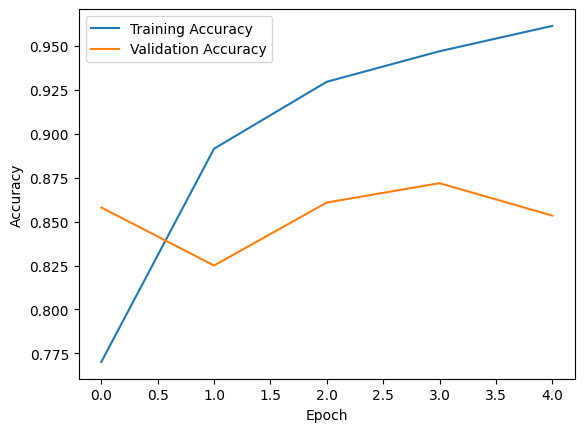

In [11]:
# 8. Plot training accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()